# Задание 8. Оффлайн тестирование рекомендательных моделей

В работе исследуются методы оффлайн оценки рекомендательных систем.

Используются пять рекомендательных моделей:
- SVD
- UserKNN
- ItemKNN
- Content-Based
- Hybrid

Для оценки применяются:
- наивная оценка Precision@3;
- Direct Method (DM);
- Inverse Propensity Scoring (IPS);
- Self-Normalized IPS (SNIPS).

Используется датасет Goodbooks-10k Extended и те же параметры рекомендательных моделей, которые были выбраны в предыдущих работах.

## Постановка задачи

Для каждой модели формируется список из трех рекомендаций.

Наивная оценка сравнивает рекомендации непосредственно с тестовыми релевантными книгами.

Direct Method использует отдельную модель оценки награды, обученную на исторических данных.

IPS и SNIPS используют информацию о logging policy. Так как исходный датасет не содержит вероятностей показа, в эксперименте используется синтетическая logging policy с известными вероятностями выбора.

В качестве награды используется бинарное значение:
1 — книга релевантна пользователю;
0 — книга нерелевантна.

Для IPS и SNIPS целевая политика равномерно выбирает одну из трех рекомендованных книг. Поэтому оценка соответствует средней награде для Top-3 и сопоставима с Precision@3.

## Загрузка и подготовка данных

Используется тот же датасет Goodbooks-10k Extended.

Данные разделяются на train и test в отношении 80/20. Релевантными считаются оценки не ниже 4.

Для эксперимента используется та же выборка из 200 пользователей, для которых в тестовой части есть хотя бы одна релевантная книга.

In [1]:
import time,warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.sparse import csr_matrix
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import normalize
from sklearn.metrics.pairwise import linear_kernel
from sklearn.decomposition import TruncatedSVD
from sklearn.neighbors import NearestNeighbors
from sklearn.linear_model import LogisticRegression

warnings.filterwarnings('ignore')

DATA_DIR = 'goodbooks-10k-extended'
PARAMS = {
    'TEST_SIZE':0.20,'RANDOM_STATE':42,'RELEVANCE_THRESHOLD':4,
    'N_EVAL_USERS':200,'TOP_N':3,
    'SVD_COMPONENTS':10,'USER_K':50,'ITEM_K':50,
    'CB_MIN_LIKE':3,'CB_PROFILE_ITEMS':50,'CB_NGRAM_RANGE':(1,5),
    'CB_MAX_FEATURES':30000,'HYBRID_CB_CANDIDATES':800,
    'LOG_EVENTS_PER_USER':30,'N_CF_RUNS':20,
    'POPULARITY_POWER':0.75,'POPULARITY_SMOOTH':0.05
}
np.random.seed(PARAMS['RANDOM_STATE'])

In [2]:
def load_data():
    ratings = pd.read_csv(f'{DATA_DIR}/ratings.csv',usecols=['user_id','book_id','rating'])
    books = pd.read_csv(f'{DATA_DIR}/books_enriched.csv')
    if 'book_id' not in books.columns: books = books.rename(columns={books.columns[0]:'book_id'})
    ratings = ratings.dropna(subset=['user_id','book_id','rating']).copy()
    books = books.dropna(subset=['book_id']).copy()
    ratings[['user_id','book_id']] = ratings[['user_id','book_id']].astype(np.int32)
    ratings['rating'] = ratings['rating'].astype(np.float32)
    books['book_id'] = books['book_id'].astype(np.int32)
    for col in ['title','authors','genres','description']:
        if col not in books.columns: books[col] = ''
        books[col] = books[col].fillna('').astype(str)
    return ratings,books

ratings_df,books_df = load_data()
train_df,test_df = train_test_split(ratings_df,test_size=PARAMS['TEST_SIZE'],random_state=PARAMS['RANDOM_STATE'])

book_ids = pd.Index(np.sort(train_df['book_id'].unique()))
book_to_idx = pd.Series(np.arange(len(book_ids)),index=book_ids)
user_ids = pd.Index(np.sort(train_df['user_id'].unique()))
user_to_idx = pd.Series(np.arange(len(user_ids)),index=user_ids)

rows = train_df['user_id'].map(user_to_idx).to_numpy()
cols = train_df['book_id'].map(book_to_idx).to_numpy()
data = train_df['rating'].to_numpy(dtype=np.float32)
R = csr_matrix((data,(rows,cols)),shape=(len(user_ids),len(book_ids)))

test_relevant = {
    int(uid):set(g.loc[g['rating']>=PARAMS['RELEVANCE_THRESHOLD'],'book_id'])
    for uid,g in test_df.groupby('user_id')
}

candidate_users = np.array([uid for uid in train_df['user_id'].unique() if uid in test_relevant and len(test_relevant[uid])>0])
np.random.seed(PARAMS['RANDOM_STATE'])
sample_eval_users = np.random.choice(candidate_users,size=min(PARAMS['N_EVAL_USERS'],len(candidate_users)),replace=False)

user_row_cache = {int(uid):int(user_to_idx[uid]) for uid in sample_eval_users}
seen_cache = {int(uid):set(train_df.loc[train_df['user_id']==uid,'book_id']) for uid in sample_eval_users}

print(f'Пользователей: {len(user_ids):,}')
print(f'Книг: {len(book_ids):,}')
print(f'Оценок train: {len(train_df):,}')
print(f'Оценок test: {len(test_df):,}')
print(f'Пользователей для оценки: {len(sample_eval_users)}')

Пользователей: 53,424
Книг: 10,000
Оценок train: 4,781,183
Оценок test: 1,195,296
Пользователей для оценки: 200


## Параметры рекомендательных моделей

Используются параметры из предыдущих экспериментов.

SVD: 10 компонент.

UserKNN и ItemKNN: 50 соседей.

Content-Based: минимальная оценка 3, профиль из 50 книг, диапазон n-грамм от 1 до 5, максимум 30000 признаков.

Hybrid: сначала формируется набор из 800 кандидатов Content-Based, после чего выполняется финальное ранжирование с использованием KNN.

In [3]:
svd = TruncatedSVD(n_components=PARAMS['SVD_COMPONENTS'],n_iter=7,random_state=PARAMS['RANDOM_STATE'])
start = time.time()
USER_FACTORS = svd.fit_transform(R)
print(f'SVD построен за {time.time()-start:.1f} сек.')

SVD построен за 0.4 сек.


In [4]:
user_knn = NearestNeighbors(n_neighbors=PARAMS['USER_K']+1,metric='cosine',algorithm='brute',n_jobs=-1).fit(R)
item_knn = NearestNeighbors(n_neighbors=PARAMS['ITEM_K']+1,metric='cosine',algorithm='brute',n_jobs=-1).fit(R.T)

USER_NEIGHBOR_CACHE = {}
ITEM_NEIGHBOR_CACHE = {}

eval_rows = np.array([user_row_cache[int(uid)] for uid in sample_eval_users])
distances,neighbors = user_knn.kneighbors(R[eval_rows],n_neighbors=PARAMS['USER_K']+1)

for i,uid in enumerate(sample_eval_users):
    USER_NEIGHBOR_CACHE[int(uid)] = (neighbors[i][1:],np.maximum(1-distances[i][1:],0))

liked_ids=set()
for uid in sample_eval_users:
    liked=train_df[(train_df['user_id']==uid)&(train_df['rating']>=4)].sort_values('rating',ascending=False).head(50)
    liked_ids.update(int(x) for x in liked['book_id'] if x in book_to_idx.index)

liked_ids=list(liked_ids)
start=time.time()

for pos in range(0,len(liked_ids),100):
    chunk=liked_ids[pos:pos+100]
    query_idx=[int(book_to_idx[x]) for x in chunk]
    distances,neighbors=item_knn.kneighbors(R.T[query_idx],n_neighbors=PARAMS['ITEM_K']+1)
    for j,bid in enumerate(chunk):
        ITEM_NEIGHBOR_CACHE[bid]=(neighbors[j][1:],np.maximum(1-distances[j][1:],0))

print(f'UserKNN и ItemKNN подготовлены за {time.time()-start:.1f} сек.')

UserKNN и ItemKNN подготовлены за 4.6 сек.


In [5]:
book_data=books_df.set_index('book_id').reindex(book_ids).fillna('')
book_texts=(book_data['title']+' '+book_data['authors']+' '+book_data['genres'].str.replace('|',' ',regex=False)+' '+book_data['description'])

vectorizer=TfidfVectorizer(max_features=PARAMS['CB_MAX_FEATURES'],ngram_range=PARAMS['CB_NGRAM_RANGE'],min_df=2,max_df=0.95,sublinear_tf=True,strip_accents='unicode')
start=time.time()
TFIDF=vectorizer.fit_transform(book_texts)
print(f'TF-IDF построен за {time.time()-start:.1f} сек.')
print(f'Размер матрицы: {TFIDF.shape}')

TF-IDF построен за 18.9 сек.
Размер матрицы: (10000, 30000)


## Формирование рекомендаций

Для каждой модели вычисляются Top-3 рекомендации.

Из рекомендаций исключаются книги, которые пользователь уже оценивал в train.

In [6]:
ARMS=['SVD','UserKNN','ItemKNN','Content','Hybrid']

def top_ids(scores,n=3,seen=None):
    scores=np.asarray(scores).copy()
    if seen:
        idx=[book_to_idx[x] for x in seen if x in book_to_idx.index]
        scores[idx]=-np.inf
    k=min(n,len(scores))
    order=np.argpartition(-scores,k-1)[:k]
    order=order[np.argsort(-scores[order])]
    return [int(book_ids[i]) for i in order]

def rec_svd(uid,n=3):
    uidx=user_row_cache[int(uid)]
    scores=USER_FACTORS[uidx]@svd.components_
    return top_ids(scores,n,seen_cache[int(uid)])

def user_scores(uid):
    neighbors,sims=USER_NEIGHBOR_CACHE[int(uid)]
    return np.asarray(R[neighbors].multiply(sims[:,None]).sum(axis=0)).ravel()

def rec_user_knn(uid,n=3):
    return top_ids(user_scores(uid),n,seen_cache[int(uid)])

def item_scores(uid):
    result=np.zeros(len(book_ids),dtype=np.float32)
    liked=train_df[(train_df['user_id']==uid)&(train_df['rating']>=4)].sort_values('rating',ascending=False).head(50)
    for bid,rating in zip(liked['book_id'],liked['rating']):
        bid=int(bid)
        if bid not in ITEM_NEIGHBOR_CACHE: continue
        neighbors,sims=ITEM_NEIGHBOR_CACHE[bid]
        result[neighbors]+=sims*float(rating)
    return result

def rec_item_knn(uid,n=3):
    return top_ids(item_scores(uid),n,seen_cache[int(uid)])

def cb_profile(uid):
    liked=train_df[(train_df['user_id']==uid)&(train_df['rating']>=PARAMS['CB_MIN_LIKE'])].sort_values('rating',ascending=False).head(PARAMS['CB_PROFILE_ITEMS'])
    if liked.empty: return None
    idxs=liked['book_id'].map(book_to_idx).to_numpy()
    weights=liked['rating'].to_numpy(dtype=np.float32)
    return normalize(csr_matrix(TFIDF[idxs].multiply(weights[:,None]).sum(axis=0)))

def cb_scores(uid):
    profile=cb_profile(uid)
    if profile is None: return np.zeros(len(book_ids))
    return linear_kernel(profile,TFIDF).ravel()

def rec_content(uid,n=3):
    return top_ids(cb_scores(uid),n,seen_cache[int(uid)])

def rec_hybrid(uid,n=3):
    cb=cb_scores(uid)
    candidate_ids=top_ids(cb,PARAMS['HYBRID_CB_CANDIDATES'],seen_cache[int(uid)])
    us=user_scores(uid)
    ins=item_scores(uid)
    candidate_idx=[book_to_idx[x] for x in candidate_ids]
    scores=0.5*us[candidate_idx]+0.5*ins[candidate_idx]
    order=np.argsort(-scores)[:n]
    return [candidate_ids[i] for i in order]

In [7]:
recommendation_cache={arm:{} for arm in ARMS}
start=time.time()

for i,uid in enumerate(sample_eval_users,1):
    uid=int(uid)
    recommendation_cache['SVD'][uid]=rec_svd(uid,3)
    recommendation_cache['UserKNN'][uid]=rec_user_knn(uid,3)
    recommendation_cache['ItemKNN'][uid]=rec_item_knn(uid,3)
    recommendation_cache['Content'][uid]=rec_content(uid,3)
    recommendation_cache['Hybrid'][uid]=rec_hybrid(uid,3)
    if i==1 or i%10==0 or i==len(sample_eval_users): print(f'{i}/{len(sample_eval_users)}',end='\r')

print(f'\nРекомендации рассчитаны за {time.time()-start:.1f} сек.')

200/200
Рекомендации рассчитаны за 15.1 сек.


## Наивная оценка

Наивная Precision@3 вычисляется непосредственно на тестовой выборке.

Для каждого пользователя считается доля релевантных книг среди трех рекомендованных. После этого значения усредняются по пользователям.

In [8]:
naive_precision=[]

for arm in ARMS:
    values=[]
    for uid in sample_eval_users:
        uid=int(uid)
        recs=recommendation_cache[arm][uid]
        relevant=test_relevant[uid]
        values.append(sum(x in relevant for x in recs)/3)
    naive_precision.append(np.mean(values))

naive_df=pd.DataFrame({'Model':ARMS,'Precision@3':naive_precision})
display(naive_df.round(6))

,Model,Precision@3
0,SVD,0.281667
1,UserKNN,0.371667
2,ItemKNN,0.321667
3,Content,0.173333
4,Hybrid,0.371667


## Синтетическая logging policy

Исходный датасет не содержит propensity score — вероятности, с которой конкретная книга была показана пользователю.

Поэтому для демонстрации IPS и SNIPS создается синтетический offline-лог.

Logging policy выбирает книги с вероятностью, зависящей от их популярности в train. Добавляется небольшое сглаживание, поэтому каждая книга имеет ненулевую вероятность выбора.

Для каждой выбранной книги награда определяется по тестовой выборке пользователя.

Это учебная offline-симуляция, а не восстановление реальной logging policy исходного сервиса.

In [9]:
item_popularity=train_df.groupby('book_id').size().reindex(book_ids,fill_value=0).to_numpy(dtype=np.float64)
log_weights=PARAMS['POPULARITY_SMOOTH']+np.power(item_popularity,PARAMS['POPULARITY_POWER'])

logging_candidates={}
logging_propensities={}

for uid in sample_eval_users:
    uid=int(uid)
    available=np.array([i for i,bid in enumerate(book_ids) if bid not in seen_cache[uid]],dtype=np.int32)
    weights=log_weights[available]
    probs=weights/weights.sum()
    logging_candidates[uid]=available
    logging_propensities[uid]=probs

print('Logging policy подготовлена.')

Logging policy подготовлена.


## Direct Method

Direct Method оценивает награду непосредственно с помощью модели, которая предсказывает вероятность положительной реакции пользователя.

В качестве reward model используется SVD, обученный на train.

Дополнительно обучается логистическая калибровка, которая преобразует SVD-оценку в вероятность релевантности.

После этого для каждой модели берется среднее предсказание reward model по ее Top-3 рекомендациям.

In [10]:
train_users=train_df['user_id'].map(user_to_idx).to_numpy()
train_books=train_df['book_id'].map(book_to_idx).to_numpy()
svd_train_scores=np.sum(USER_FACTORS[train_users]*svd.components_[:,train_books].T,axis=1)
train_binary=(train_df['rating'].to_numpy()>=PARAMS['RELEVANCE_THRESHOLD']).astype(int)

reward_calibrator=LogisticRegression(max_iter=200)
reward_calibrator.fit(svd_train_scores.reshape(-1,1),train_binary)

def dm_reward(uid,bid):
    uidx=user_row_cache[int(uid)]
    bidx=int(book_to_idx[int(bid)])
    score=USER_FACTORS[uidx]@svd.components_[:,bidx]
    return reward_calibrator.predict_proba([[score]])[0,1]

dm_values=[]
for arm in ARMS:
    user_values=[]
    for uid in sample_eval_users:
        uid=int(uid)
        user_values.append(np.mean([dm_reward(uid,bid) for bid in recommendation_cache[arm][uid]]))
    dm_values.append(np.mean(user_values))

dm_df=pd.DataFrame({'Model':ARMS,'DM':dm_values})
display(dm_df.round(6))

,Model,DM
0,SVD,0.806181
1,UserKNN,0.771187
2,ItemKNN,0.766110
3,Content,0.666986
4,Hybrid,0.761562


## IPS и SNIPS

Для целевой политики каждая из трех рекомендаций имеет вероятность 1/3.

IPS увеличивает вклад наблюдения, если logging policy выбирала его с небольшой вероятностью.

SNIPS использует ту же идею, но дополнительно нормирует веса. Это обычно уменьшает влияние слишком больших propensity weights.

Для каждой модели выполняется несколько независимых генераций offline-лога, после чего рассчитываются среднее и стандартное отклонение оценок.

In [11]:
def generate_log(seed):
    rng=np.random.default_rng(seed)
    rows=[]
    for uid in sample_eval_users:
        uid=int(uid)
        candidates=logging_candidates[uid]
        probs=logging_propensities[uid]
        positions=rng.choice(len(candidates),size=PARAMS['LOG_EVENTS_PER_USER'],replace=True,p=probs)
        for pos in positions:
            bidx=int(candidates[pos])
            bid=int(book_ids[bidx])
            p=float(probs[pos])
            reward=int(bid in test_relevant[uid])
            rows.append((uid,bid,reward,p))
    return pd.DataFrame(rows,columns=['user_id','book_id','reward','propensity'])

In [12]:
def evaluate_counterfactual(log_df,arm):
    top3={int(uid):set(recommendation_cache[arm][int(uid)]) for uid in sample_eval_users}
    q=np.array([1/3 if int(bid) in top3[int(uid)] else 0 for uid,bid in zip(log_df['user_id'],log_df['book_id'])],dtype=float)
    p=log_df['propensity'].to_numpy()
    r=log_df['reward'].to_numpy()
    w=q/p
    ips=np.mean(r*w)
    snips=np.sum(r*w)/np.sum(w) if np.sum(w)>0 else 0
    return ips,snips

In [13]:
cf_results=[]

for run in range(PARAMS['N_CF_RUNS']):
    log_df=generate_log(1000+run)
    for arm in ARMS:
        ips,snips=evaluate_counterfactual(log_df,arm)
        cf_results.append({'Run':run,'Model':arm,'IPS':ips,'SNIPS':snips})

cf_df=pd.DataFrame(cf_results)

cf_summary=cf_df.groupby('Model').agg(
    IPS_Mean=('IPS','mean'),
    IPS_Std=('IPS','std'),
    SNIPS_Mean=('SNIPS','mean'),
    SNIPS_Std=('SNIPS','std')
).reindex(ARMS).reset_index()

display(cf_summary.round(6))

,Model,IPS_Mean,IPS_Std,SNIPS_Mean,SNIPS_Std
0,SVD,0.298777,0.111124,0.298532,0.101359
1,UserKNN,0.414843,0.331887,0.400571,0.167518
2,ItemKNN,0.351804,0.370630,0.272073,0.177126
3,Content,0.221837,0.463391,0.234850,0.362965
4,Hybrid,0.460082,0.421592,0.382121,0.201471


## Сравнение методов

Объединим результаты наивной оценки, Direct Method, IPS и SNIPS в одну таблицу.

Для IPS и SNIPS приводятся средние значения по нескольким генерациям offline-лога.

In [14]:
result_df=naive_df.merge(dm_df,on='Model').merge(cf_summary,on='Model')
display(result_df.round(6))

,Model,Precision@3,DM,IPS_Mean,IPS_Std,SNIPS_Mean,SNIPS_Std
0,SVD,0.281667,0.806181,0.298777,0.111124,0.298532,0.101359
1,UserKNN,0.371667,0.771187,0.414843,0.331887,0.400571,0.167518
2,ItemKNN,0.321667,0.766110,0.351804,0.370630,0.272073,0.177126
3,Content,0.173333,0.666986,0.221837,0.463391,0.234850,0.362965
4,Hybrid,0.371667,0.761562,0.460082,0.421592,0.382121,0.201471


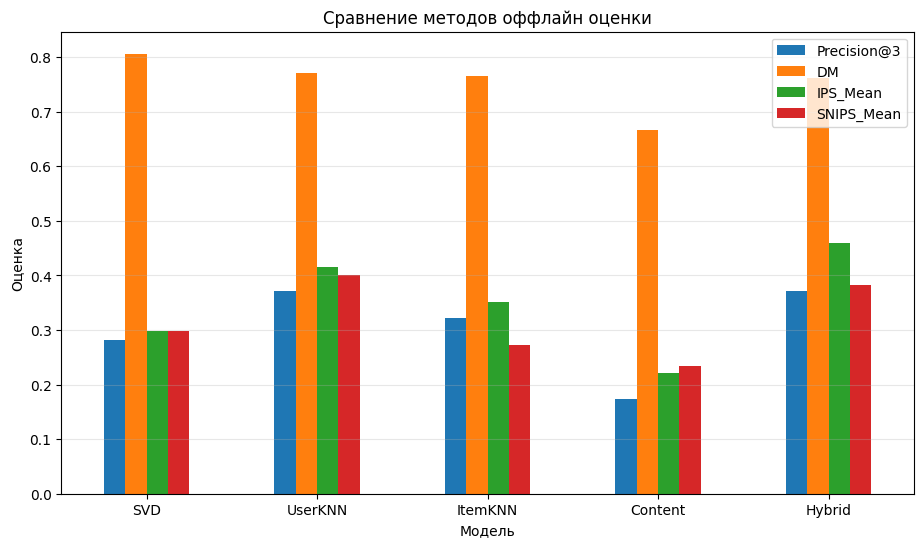

In [15]:
plot_df=result_df.set_index('Model')[['Precision@3','DM','IPS_Mean','SNIPS_Mean']]
ax=plot_df.plot(kind='bar',figsize=(11,6))
ax.set_xlabel('Модель')
ax.set_ylabel('Оценка')
ax.set_title('Сравнение методов оффлайн оценки')
plt.xticks(rotation=0)
plt.grid(axis='y',alpha=0.3)
plt.show()

## Стабильность контрфактуальных оценок

IPS может иметь высокую дисперсию из-за обратных propensity weights.

SNIPS дополнительно нормирует IPS-весы, поэтому его оценка обычно становится менее чувствительной к отдельным наблюдениям с очень маленькой propensity.

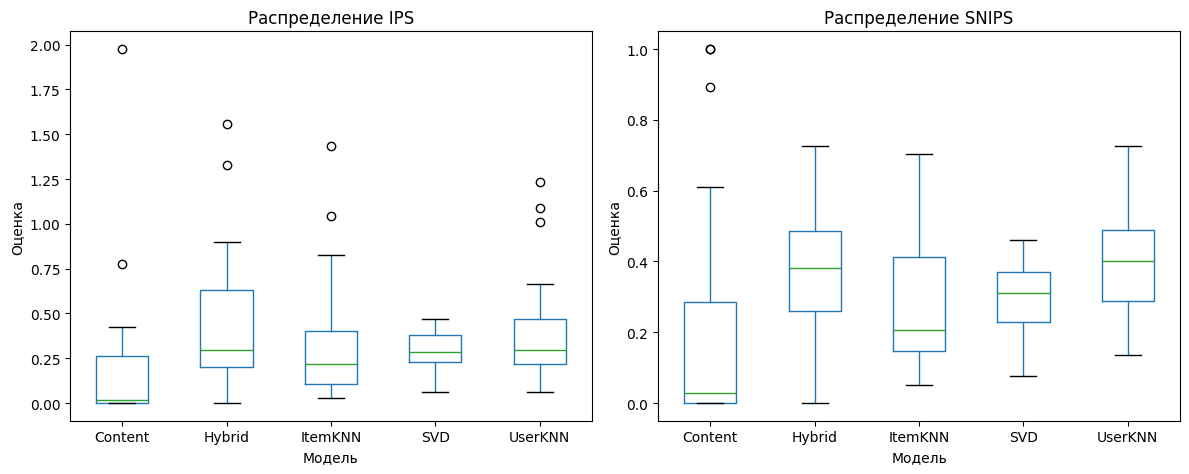

In [16]:
fig,axes=plt.subplots(1,2,figsize=(12,5))

cf_df.boxplot(column='IPS',by='Model',ax=axes[0],grid=False)
axes[0].set_title('Распределение IPS')
axes[0].set_xlabel('Модель')
axes[0].set_ylabel('Оценка')

cf_df.boxplot(column='SNIPS',by='Model',ax=axes[1],grid=False)
axes[1].set_title('Распределение SNIPS')
axes[1].set_xlabel('Модель')
axes[1].set_ylabel('Оценка')

plt.suptitle('')
plt.tight_layout()
plt.show()

## Интерпретация результатов

Наивная Precision@3 показывает фактическое качество рекомендаций непосредственно на тестовой выборке. В этом случае наиболее успешно себя показали UserKNN и Hybrid, а Content-Based дал наиболее низкий результат.

Direct Method использует reward model, поэтому его оценки отличаются от наивной Precision@3. Наибольшую оценку получил SVD, а Content-Based снова показал наиболее низкий результат. Это показывает зависимость Direct Method от качества используемой модели предсказания награды.

IPS учитывает вероятность появления объекта в logging policy. По этому методу наибольшую оценку получил Hybrid, близкий результат показал UserKNN, а Content-Based снова оказался ниже остальных моделей. При этом разброс результатов у IPS достаточно заметный, особенно для некоторых моделей.

SNIPS дополнительно нормирует IPS-веса. В результате оценки стали более устойчивыми по сравнению с IPS. Наиболее высокую оценку получил UserKNN, а Hybrid также сохранил высокое положение. Content-Based продолжил показывать наиболее низкие результаты.

Различия между методами показывают, что одна и та же рекомендательная модель может получать разные оценки в зависимости от способа оффлайн тестирования. Поэтому при анализе результатов необходимо учитывать не только саму модель, но и используемый метод оценивания.

Контрфактуальные результаты в данной работе следует рассматривать как результаты offline-симуляции. Реальные IPS и SNIPS требуют настоящего лога взаимодействий и известных или надежно оцененных propensity scores.

## Выводы

В работе были исследованы методы оффлайн оценки пяти рекомендательных моделей: SVD, UserKNN, ItemKNN, Content-Based и Hybrid.

Наивная Precision@3 позволяет непосредственно оценить качество рекомендаций на отложенной тестовой выборке.

Direct Method оценивает качество через предсказание награды, поэтому чувствителен к ошибкам reward model.

IPS учитывает смещение, возникающее из-за политики показа объектов, но может иметь высокую дисперсию при маленьких вероятностях наблюдения.

SNIPS дополнительно нормирует веса и позволяет сделать контрфактуальную оценку более устойчивой.

Таким образом, контрфактуальные методы позволяют проводить оффлайн тестирование с учетом политики сбора данных, однако их качество напрямую зависит от корректности logging policy и propensity scores. Для реальной рекомендательной системы наиболее важным источником для таких методов является полноценный лог показов и взаимодействий пользователей.